In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd

In [2]:
def naive_matrix_multiplication(A, B):
    n = len(A)
    C = [[0] * n for _ in range(n)]
    for i in range(n):
        for j in range(n):
            for k in range(n):
                C[i][j] += A[i][k] * B[k][j]
    return C

   matrix_number     size  naive_runtime_s  numpy_runtime_s  max_abs_error
0              1      3x3         0.000039         0.000171   2.220446e-16
1              2      6x6         0.000170         0.000034   4.440892e-16
2              3    12x12         0.000802         0.000033   8.881784e-16
3              4    24x24         0.006561         0.000064   2.664535e-15
4              5    48x48         0.019812         0.000088   5.329071e-15
5              6    96x96         0.166719         0.000511   1.065814e-14
6              7  192x192         1.299458         0.002026   2.131628e-14
7              8  384x384        11.484255         0.003946   2.557954e-13


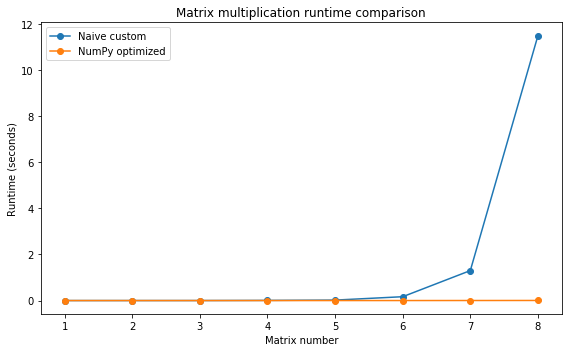

In [3]:
sizes = [3 * (2 ** i) for i in range(8)]

rng = np.random.default_rng(42)
results = []

for idx, n in enumerate(sizes, start=1):
    A_np = rng.random((n, n))
    B_np = rng.random((n, n))

    A_list = A_np.tolist()
    B_list = B_np.tolist()


    t0 = time.perf_counter()
    C_naive = naive_matrix_multiplication(A_list, B_list)
    t1 = time.perf_counter()
    naive_time = t1 - t0

    t2 = time.perf_counter()
    C_numpy = A_np @ B_np
    t3 = time.perf_counter()
    numpy_time = t3 - t2


    max_abs_err = np.max(np.abs(np.array(C_naive) - C_numpy))

    results.append({
        "matrix_number": idx,
        "size": f"{n}x{n}",
        "naive_runtime_s": naive_time,
        "numpy_runtime_s": numpy_time,
        "max_abs_error": max_abs_err,
    })

df = pd.DataFrame(results)
print(df)

plt.figure(figsize=(8, 5))
plt.plot(df["matrix_number"], df["naive_runtime_s"], marker="o", label="Naive custom")
plt.plot(df["matrix_number"], df["numpy_runtime_s"], marker="o", label="NumPy optimized")
plt.xlabel("Matrix number")
plt.ylabel("Runtime (seconds)")
plt.title("Matrix multiplication runtime comparison")
plt.xticks(df["matrix_number"])
plt.legend()
plt.tight_layout()
plt.show()